In [2]:
import pandas as pd

In [4]:
df = pd.read_csv('../outputs/test_exons_with_pretuner.csv')
df.head

<bound method NDFrame.head of         CHROM        POS REF ALT     exon_id  ensembl_exon_id  \
0       chr11   47343262   G   T  MYBPC3_e14  ENSE00001799700   
1       chr11   47343260   T   G  MYBPC3_e14  ENSE00001799700   
2       chr11   47343260   T   C  MYBPC3_e14  ENSE00001799700   
3       chr11   47343260   T   A  MYBPC3_e14  ENSE00001799700   
4       chr11   47343261   T   G  MYBPC3_e14  ENSE00001799700   
...       ...        ...  ..  ..         ...              ...   
150495  chr11  108343228   C   G     ATM_e57  ENSE00003611442   
150496  chr11  108343228   C   T     ATM_e57  ENSE00003611442   
150497  chr11  108343225   G   T     ATM_e57  ENSE00003611442   
150498  chr11  108343224   G   T     ATM_e57  ENSE00003611442   
150499  chr11  108343222   G   T     ATM_e57  ENSE00003611442   

             variant_id                                             nt_seq  \
0       MYBPC3_e14_C71A  TCTCTCTCCTTTTGTCTCGGGCTCACTTCCTCCCGTCGGGAACACT...   
1       MYBPC3_e14_A73C  TCTCTCTC

In [12]:
df['sat_5_95'] = (df['psi'] <= 5) | (df['psi'] >= 95)
df['sat_10_90'] = (df['psi'] <= 10) | (df['psi'] >= 90)


In [13]:
print(df['sat_5_95'].value_counts())
print(df['sat_5_95'].mean())
print(df['sat_10_90'].value_counts())
print(df['sat_10_90'].mean())

sat_5_95
False    136846
True      13654
Name: count, dtype: int64
0.09072425249169436
sat_10_90
False    112899
True      37601
Name: count, dtype: int64
0.2498405315614618


In [14]:
exon_sat = (df.groupby("exon_id")[['sat_5_95','sat_10_90']].mean())

In [15]:
exon_sat.head()

,sat_5_95,sat_10_90
exon_id,,
ABCA4_e10,0.003413,0.013652
ABCA4_e9,0.000000,0.007177
ABCB11_e12,0.000000,0.966867
ABCB11_e4,0.038710,0.058065
ABCC2_e21,0.014888,0.029777


In [16]:
exon_sat["sat_5_95_50pct"] = exon_sat["sat_5_95"] >= 0.50
exon_sat["sat_5_95_75pct"] = exon_sat["sat_5_95"] >= 0.75
exon_sat["sat_5_95_90pct"] = exon_sat["sat_5_95"] >= 0.90

exon_sat["sat_10_90_50pct"] = exon_sat["sat_10_90"] >= 0.50
exon_sat["sat_10_90_75pct"] = exon_sat["sat_10_90"] >= 0.75
exon_sat["sat_10_90_90pct"] = exon_sat["sat_10_90"] >= 0.90

In [17]:
df["sat_low_5"] = df["psi"] <= 5
df["sat_high_95"] = df["psi"] >= 95

df["sat_low_10"] = df["psi"] <= 10
df["sat_high_90"] = df["psi"] >= 90

In [18]:
exon_sat.head()

,sat_5_95,sat_10_90,sat_5_95_50pct,sat_5_95_75pct,sat_5_95_90pct,sat_10_90_50pct,sat_10_90_75pct,sat_10_90_90pct
exon_id,,,,,,,,
ABCA4_e10,0.003413,0.013652,False,False,False,False,False,False
ABCA4_e9,0.000000,0.007177,False,False,False,False,False,False
ABCB11_e12,0.000000,0.966867,False,False,False,True,True,True
ABCB11_e4,0.038710,0.058065,False,False,False,False,False,False
ABCC2_e21,0.014888,0.029777,False,False,False,False,False,False


In [19]:
df[['sat_low_5','sat_high_95','sat_low_10','sat_high_90']].head(20)

,sat_low_5,sat_high_95,sat_low_10,sat_high_90
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
5,False,False,False,False
6,False,False,False,False
7,False,False,False,False
8,False,False,False,False
9,True,False,True,False


In [ ]:
# Summary of columns
#sat_5_95, sat_10_90
#account of whether a variant is saturated or not according to percentiles

#(In exon_sat)
#sat_5_95_50pct, sat_5_95_75pct, sat_5_95_90pct
#account of whether or not an exon is saturated according to percentile of variants saturated by 5/95 percentile
#sat_10_90_50pct, sat_10_90_75pct, sat_10_90_90pct
#account of whether or not an exon is saturated according to percentile of variants saturated by 10/90 percentile

#sat_low_5, sat_high_95, sat_low_10, sat_high_90
#label of which side (low/high) a variant was recorded as saturated

In [31]:
sat_sum_5_95_cols = ['sat_5_95_50pct','sat_5_95_75pct', 'sat_5_95_90pct']
sat_sum_10_90_cols = ['sat_10_90_50pct','sat_10_90_75pct', 'sat_10_90_90pct']

for col in sat_sum_5_95_cols:
    print(exon_sat[col].value_counts())
    counts = exon_sat[col].value_counts()
    print(f'Saturated percentage: {counts[True] / (counts[True] + counts[False]) * 100}\n')

sat_5_95_50pct
False    560
True      41
Name: count, dtype: int64
Saturated percentage: 6.821963394342761

sat_5_95_75pct
False    579
True      22
Name: count, dtype: int64
Saturated percentage: 3.6605657237936775

sat_5_95_90pct
False    589
True      12
Name: count, dtype: int64
Saturated percentage: 1.9966722129783694



In [32]:
for col in sat_sum_10_90_cols:
    print(exon_sat[col].value_counts())
    counts = exon_sat[col].value_counts()
    print(f'Saturated percentage: {counts[True] / (counts[True] + counts[False]) * 100}\n')

sat_10_90_50pct
False    481
True     120
Name: count, dtype: int64
Saturated percentage: 19.966722129783694

sat_10_90_75pct
False    518
True      83
Name: count, dtype: int64
Saturated percentage: 13.810316139767053

sat_10_90_90pct
False    553
True      48
Name: count, dtype: int64
Saturated percentage: 7.9866888519134775



In [76]:
#Exploration of OLS slope after filtering out saturated exons

import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
from scipy.stats import linregress 

slopes = [] 

for exon_id, group in df.groupby('exon_id'):
    g = group.dropna(subset=['pretuner', 'psi'])
    if len(g) < 2: continue 

    x = g['pretuner'].to_numpy() 
    y = g['logit_psi'].to_numpy() 

    slope, intercept, r, p, stderr = linregress(x,y) 

    slopes.append({
        "exon_id": exon_id,
        "slope": slope, 
        "pearson_r": r, 
        "n": len(g),
    })

slope_df = pd.DataFrame(slopes)


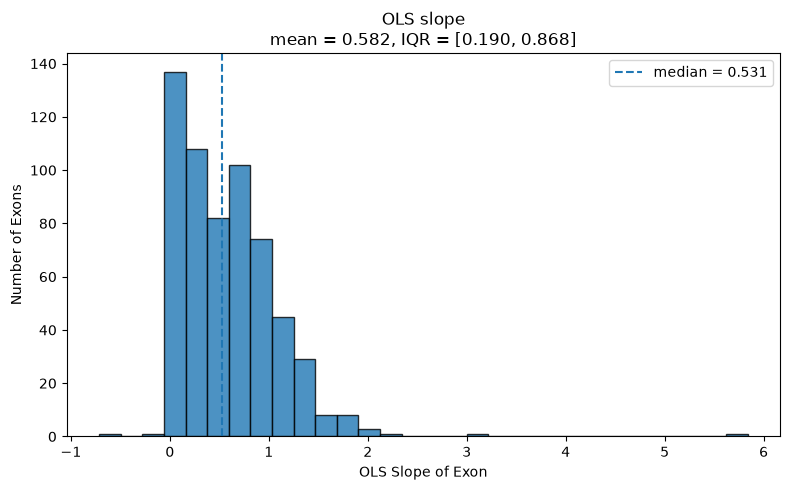

In [78]:
s = slope_df["slope"].dropna()

mean = s.mean()
median = s.median() 
q1 = s.quantile(0.25)
q3 = s.quantile(0.75) 

plt.figure(figsize=(8,5)) 
plt.hist(
    s,
    bins=30,
    edgecolor='black',
    alpha=0.8
)

plt.axvline(
    median,
    linestyle='--',
    label=f'median = {median:.3f}',
)

plt.xlabel("OLS Slope of Exon")
plt.ylabel("Number of Exons") 
plt.title(
    "OLS slope\n"
    f"mean = {mean:.3f}, IQR = [{q1:.3f}, {q3:.3f}]"
)
plt.legend()
plt.tight_layout()
plt.show()


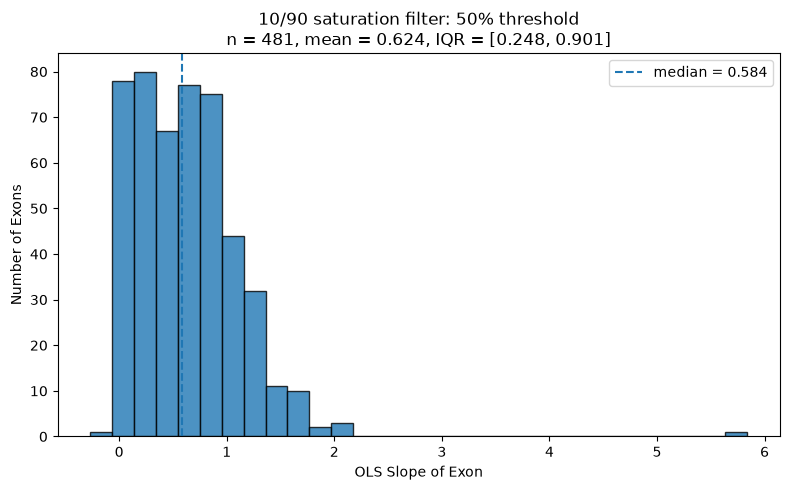

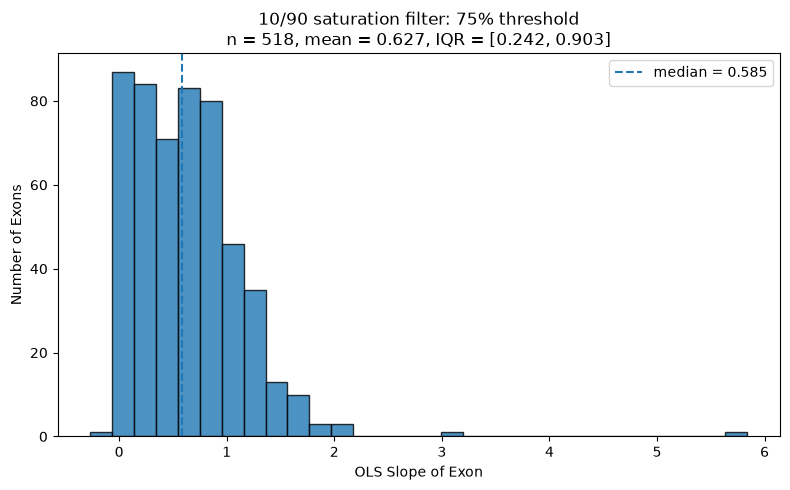

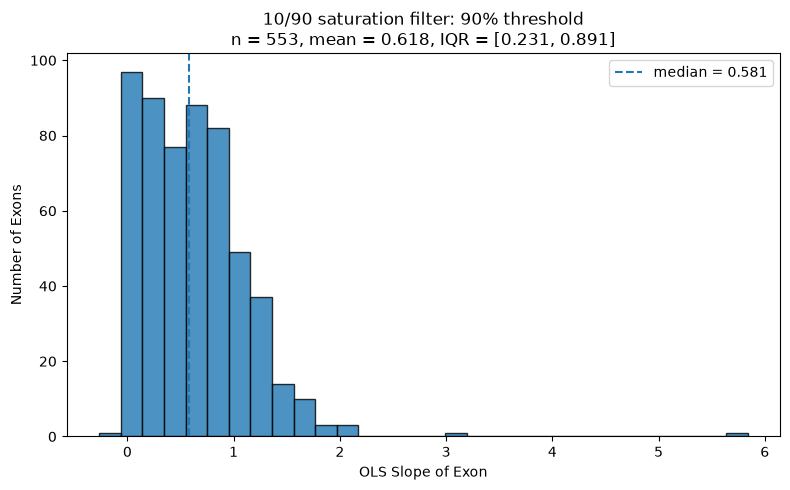

In [81]:
# examining the three thresholds for 10/90 saturation by the individual variants
threshold_cols = [
    "sat_10_90_50pct",
    "sat_10_90_75pct",
    "sat_10_90_90pct",
]


for col in threshold_cols:
    keep_exons = exon_sat.index[~exon_sat[col]]
    filtered = slope_df[
        slope_df['exon_id'].isin(keep_exons)
    ]

    s = filtered['slope'].dropna() 

    mean = s.mean()
    median = s.median()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)

    plt.figure(figsize=(8, 5))

    plt.hist(
        s,
        bins=30,
        edgecolor="black",
        alpha=0.8,
    )

    plt.axvline(
        median,
        linestyle="--",
        label=f"median = {median:.3f}",
    )

    pct = col.split("_")[-1].replace("pct", "")
    plt.xlabel("OLS Slope of Exon")
    plt.ylabel("Number of Exons")

    plt.title(
        f"10/90 saturation filter: {pct}% threshold\n"
        f"n = {len(s)}, mean = {mean:.3f}, "
        f"IQR = [{q1:.3f}, {q3:.3f}]"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()
    



In [82]:
low_slope_threshold = 0.1

threshold_cols = [
    "sat_10_90_50pct",
    "sat_10_90_75pct",
    "sat_10_90_90pct",
]

for col in threshold_cols:
    keep_exons = exon_sat.index[~exon_sat[col]]

    filtered = slope_df[
        slope_df["exon_id"].isin(keep_exons)
    ]

    low_slope = filtered[
        filtered["slope"] < low_slope_threshold
    ]

    pct = col.split("_")[-1].replace("pct", "")

    print(f"{pct}% saturation threshold")
    print(f"Total exons kept: {len(filtered)}")
    print(f"Low-slope exons (< {low_slope_threshold}): {len(low_slope)}")
    print(
        f"Fraction low-slope: "
        f"{len(low_slope) / len(filtered):.3f}"
    )
    print()




50% saturation threshold
Total exons kept: 481
Low-slope exons (< 0.1): 61
Fraction low-slope: 0.127

75% saturation threshold
Total exons kept: 518
Low-slope exons (< 0.1): 69
Fraction low-slope: 0.133

90% saturation threshold
Total exons kept: 553
Low-slope exons (< 0.1): 75
Fraction low-slope: 0.136



In [83]:
low_slope_all = slope_df[
    slope_df["slope"] < low_slope_threshold
]

print("No saturation filtering")
print(f"Total exons: {len(slope_df)}")
print(f"Low-slope exons: {len(low_slope_all)}")
print(
    f"Fraction low-slope: "
    f"{len(low_slope_all) / len(slope_df):.3f}"
)

No saturation filtering
Total exons: 601
Low-slope exons: 100
Fraction low-slope: 0.166


In [85]:
# Identify the stubborn exons that were not filtered by the 75pct 10/90 saturation filter

keep_exons = exon_sat.index[~exon_sat['sat_10_90_75pct']]

stubborn_75 = slope_df[
    slope_df['exon_id'].isin(keep_exons) &
    (slope_df['slope'] < 0.1)
]

print(
    stubborn_75.sort_values("slope")[
        ["exon_id", "slope", "pearson_r", "n"]
    ]
)
print(stubborn_75.shape)

        exon_id     slope  pearson_r    n
88     BRCA2_e6 -0.266831  -0.120611   29
86    BRCA2_e21 -0.031279  -0.102983  326
596     YAP1_e6 -0.017283  -0.013606  143
490   PRPF31_e9 -0.015806  -0.032466  150
218   DMXL2_e36 -0.009452  -0.017194  343
..          ...       ...        ...  ...
172  COL4A1_e17  0.086771   0.096146  160
60      BANP_e5  0.090188   0.240804  291
160  COL1A2_e16  0.091230   0.085659  161
351   LRP1B_e32  0.096202   0.308844  446
83    BRCA1_e20  0.099072   0.143603   87

[69 rows x 4 columns]
(69, 4)


In [86]:
# add exon length

exon_length = (
    df.groupby("exon_id")["wt_exon_length"]
      .first()
      .reset_index()
)

slope_df = slope_df.merge(
    exon_length,
    on="exon_id",
    how="left"
)

In [87]:
slope_df["stubborn"] = slope_df["slope"] < 0.1
print(
    slope_df.groupby("stubborn")["wt_exon_length"]
    .describe()
)

          count       mean        std  min    25%    50%     75%    max
stubborn                                                               
False     501.0  87.239521  35.982531  3.0  51.00   93.0  116.00  150.0
True      100.0  98.290000  36.890035  6.0  54.75  110.5  128.75  150.0


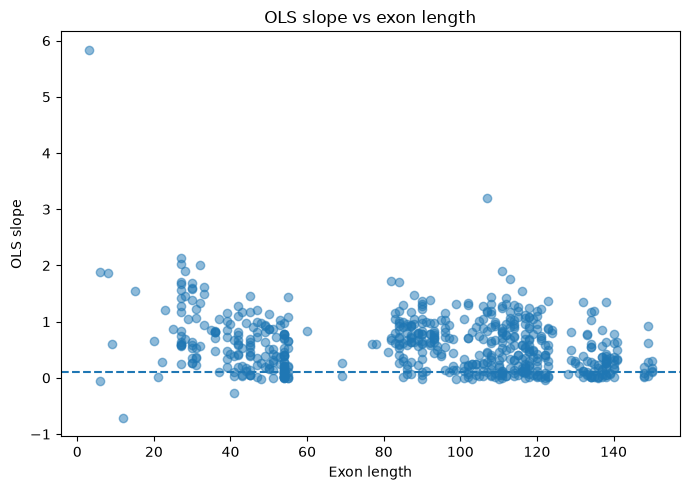

In [88]:
plt.figure(figsize=(7, 5))

plt.scatter(
    slope_df["wt_exon_length"],
    slope_df["slope"],
    alpha=0.5
)

plt.axhline(0.1, linestyle="--")

plt.xlabel("Exon length")
plt.ylabel("OLS slope")
plt.title("OLS slope vs exon length")

plt.tight_layout()
plt.show()

In [89]:
from scipy.stats import spearmanr

g = slope_df.dropna(subset=["wt_exon_length", "slope"])

rho, p = spearmanr(
    g["wt_exon_length"],
    g["slope"]
)

print("Spearman rho:", rho)
print("p-value:", p)

Spearman rho: -0.2285652258430804
p-value: 1.4543550564179304e-08


In [90]:
keep_exons = exon_sat.index[
    ~exon_sat["sat_10_90_75pct"]
]

slope_75 = slope_df[
    slope_df["exon_id"].isin(keep_exons)
].copy()

slope_75["stubborn"] = slope_75["slope"] < 0.1

print(
    slope_75.groupby("stubborn")["wt_exon_length"]
    .describe()
)

          count       mean        std   min   25%    50%    75%    max
stubborn                                                              
False     449.0  87.160356  36.849248   3.0  51.0   93.0  117.0  150.0
True       69.0  98.333333  39.743541  41.0  54.0  117.0  134.0  150.0


In [91]:
g = slope_75.dropna(
    subset=["wt_exon_length", "slope"]
)

rho, p = spearmanr(
    g["wt_exon_length"],
    g["slope"]
)

print("Spearman rho:", rho)
print("p-value:", p)

Spearman rho: -0.23821715317950834
p-value: 4.0690247550320785e-08


In [92]:
#t-test for difference in means
from scipy.stats import ttest_ind

stubborn_len = slope_75.loc[
    slope_75["stubborn"],
    "wt_exon_length"
].dropna()

normal_len = slope_75.loc[
    ~slope_75["stubborn"],
    "wt_exon_length"
].dropna()

t_stat, p = ttest_ind(
    stubborn_len,
    normal_len,
    equal_var=False   # Welch's t-test
)

print("Stubborn mean:", stubborn_len.mean())
print("Non-stubborn mean:", normal_len.mean())
print("Difference in means:", stubborn_len.mean() - normal_len.mean())
print("t-statistic:", t_stat)
print("p-value:", p)

Stubborn mean: 98.33333333333333
Non-stubborn mean: 87.16035634743875
Difference in means: 11.172976985894579
t-statistic: 2.1947400813171405
p-value: 0.030848290050583226


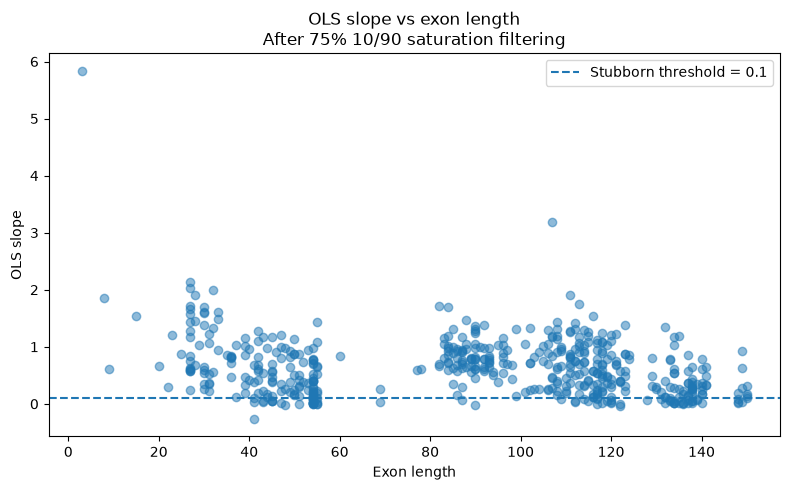

In [93]:
plt.figure(figsize=(8, 5))

plt.scatter(
    slope_75["wt_exon_length"],
    slope_75["slope"],
    alpha=0.5
)

plt.axhline(
    0.1,
    linestyle="--",
    label="Stubborn threshold = 0.1"
)

plt.xlabel("Exon length")
plt.ylabel("OLS slope")
plt.title(
    "OLS slope vs exon length\n"
    "After 75% 10/90 saturation filtering"
)

plt.legend()
plt.tight_layout()
plt.show()

In [94]:
#duplicate plots for these exons

from pathlib import Path 
import shutil 

src_dir = Path('../outputs/plots')
dst_dir = src_dir / "stubborn_75pct"

dst_dir.mkdir(exist_ok=True)
copied = 0 

for exon_id in stubborn_75['exon_id']:
    matches = list(src_dir.glob(f"{exon_id}_with_ss_pretuner_vs_measured.png"))

    if not matches:
        print(f'Missing: {exon_id}')
        continue 

    for file in matches:
        shutil.copy2(file, dst_dir / file.name)
        copied += 1

print(f'Done. Copied {copied}.')


Done. Copied 69.
